## H1ESC test set, bpnet architecture


In [25]:
countsx=20
prefix="predictions.H1ESC.withdups."+str(countsx)+"counts"
fold=str(0)
idr_peaks="test.set.0.sorted.bed"
top_peaks=20
title="H1ESC DNASE bpnet, counts x "+str(countsx)

In [26]:
import pandas as pd 
from scipy.stats import spearmanr 
from scipy.stats import pearsonr 
from scipy.special import softmax

## get ranked list of IDR peaks on chrom 1 (test chrom)

In [33]:
idr_peaks=pd.read_csv(idr_peaks,header=None,sep='\t')
idr_peaks['summit']=idr_peaks[1]+idr_peaks[9]
idr_peaks=idr_peaks.sort_values(by=[8],ascending=False)
positions=[]
count=0
for index,row in idr_peaks.iterrows(): 
    summit=row['summit']
    chrom=row[0]
    count+=1
    if count >top_peaks: 
        break
    positions.append((chrom,summit))
        

ValueError: Invalid file path or buffer object type: <class 'pandas.core.frame.DataFrame'>

In [34]:
## for plotting 
import matplotlib 
from matplotlib import pyplot as plt
plt.rcParams["figure.figsize"]=10,5

In [35]:
font = {'family' : 'normal',
        'weight' : 'bold',
        'size'   : 10}

matplotlib.rc('font', **font)

In [36]:
def run_analysis(prefix,title):
    labels_0=pd.read_hdf(".".join([prefix,fold,'labels.0']),header=None,sep='\t')
    labels_1=pd.read_hdf(".".join([prefix,fold,'labels.1']),header=None,sep='\t')
    pred_0=pd.read_hdf(".".join([prefix,fold,'predictions.0']),header=None,sep='\t')
    pred_1=pd.read_hdf(".".join([prefix,fold,'predictions.1']),header=None,sep='\t')
    #get counts profile & softmax 
    pred_0_softmax=softmax(pred_0,axis=1)
    for i in range(1,1000): 
        pred_1[i]=pred_1[0]
    pred_0_count=pred_0_softmax.multiply(pred_1,axis='index')
    plt.rcParams["figure.figsize"]=10,8
    for pos in positions[0:20]:
        fig, axes = plt.subplots(3, 1)
        probs_observed=labels_0.loc[pos].values/sum(labels_0.loc[pos].values)
        axes[0].plot(pred_0_count.loc[pos],label='Predictions',color='r')
        axes[1].plot(labels_0.loc[pos],label='Labels',color='b')
        axes[2].plot(probs_observed,label="Labels Probability",color='b')
        axes[2].plot(pred_0_softmax.loc[pos],label="Predicted Probability",color='r')    
        axes[0].set_title(title+str(pos))
        axes[0].legend()
        axes[1].legend() 
        axes[2].legend()
        plt.show() 
        
    spearman_cor=spearmanr(labels_1[0].values,pred_1[0].values)[0]
    pearson_cor=pearsonr(labels_1[0].values,pred_1[0].values)[0]
    plt.rcParams["figure.figsize"]=8,8
    plt.figure()
    plt.scatter(labels_1[0].values, pred_1[0].values ,alpha=0.1)
    plt.xlabel('Log Count Labels')
    plt.ylabel('Log Count Predictions')
    plt.title(title+" spearman R="+str(round(spearman_cor,3))+", Pearson R="+str(round(pearson_cor,3)))
    plt.legend(loc='best')
    plt.xlim(0,11)
    plt.ylim(0,11)
    plt.show()

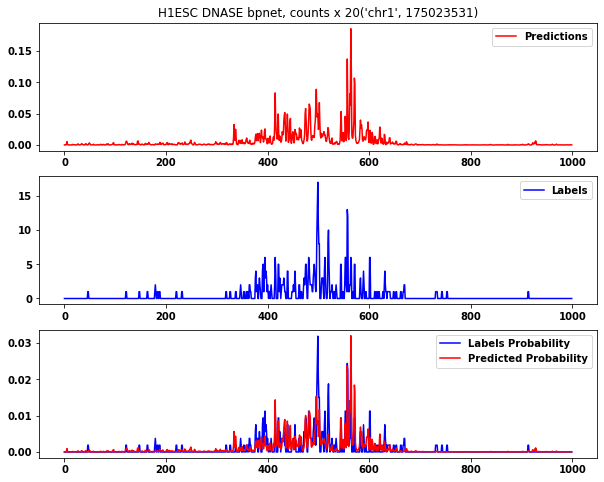

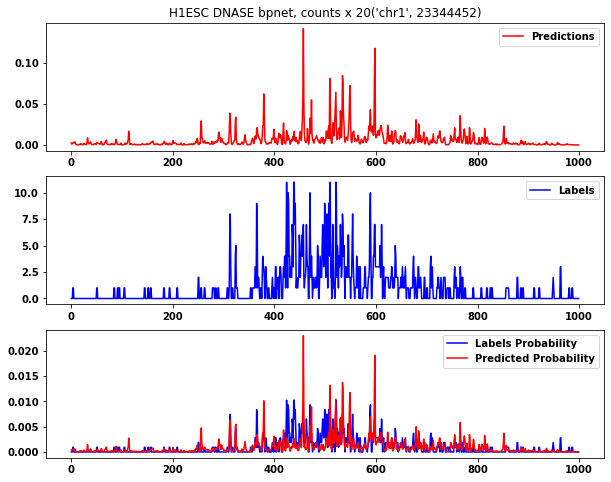

No handles with labels found to put in legend.


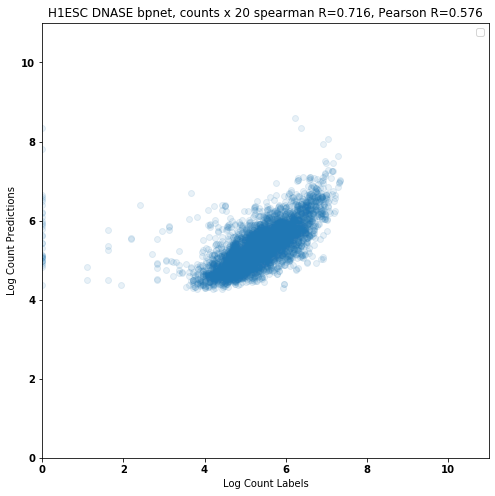

In [37]:
run_analysis(prefix,title)